In [3]:
# Install all dependencies
!pip install yfinance praw vaderSentiment feedparser pandas numpy matplotlib seaborn scikit-learn tensorflow keras requests

import yfinance as yf
import praw
import feedparser
import pandas as pd
import numpy as np
import requests
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 6.9 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=d58ed19d6319ce2170baf714c323c5ecfc384cca4d571545252946e53bc4c1fa
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k


##Added CSV upload and load all 5 data sources with shape and column checks

In [4]:
from google.colab import files

uploaded = files.upload()
# Upload: reddit_posts.csv, timeseries_dataset.csv, sentiment_labeled.csv

Saving reddit_posts.csv to reddit_posts.csv
Saving rss_articles.csv to rss_articles.csv
Saving sentiment_labeled.csv to sentiment_labeled.csv
Saving timeseries_dataset.csv to timeseries_dataset.csv
Saving twitter_posts.csv to twitter_posts.csv


In [5]:
reddit_df    = pd.read_csv("reddit_posts.csv")
ts_df        = pd.read_csv("timeseries_dataset.csv")
twitter_df   = pd.read_csv("twitter_posts.csv")
sentiment_df = pd.read_csv("sentiment_labeled.csv")
rss_df       = pd.read_csv("rss_articles.csv")

print("=== Reddit Posts ===")
print("Shape:", reddit_df.shape)
print("Columns:", reddit_df.columns.tolist())
print(reddit_df.head(2))

print("\n=== Time Series ===")
print("Shape:", ts_df.shape)
print("Columns:", ts_df.columns.tolist())
print(ts_df.head(2))

print("\n=== Twitter Posts ===")
print("Shape:", twitter_df.shape)
print("Columns:", twitter_df.columns.tolist())
print(twitter_df.head(2))

print("\n=== Sentiment Labeled ===")
print("Shape:", sentiment_df.shape)
print("Columns:", sentiment_df.columns.tolist())
print(sentiment_df.head(2))

print("\n=== RSS Articles ===")
print("Shape:", rss_df.shape)
print("Columns:", rss_df.columns.tolist())
print(rss_df.head(2))

=== Reddit Posts ===
Shape: (15, 4)
Columns: ['timestamp', 'source', 'title', 'text']
                    timestamp  source  \
0  2026-05-09T17:53:52.279827  reddit   
1  2026-05-09T17:53:52.279827  reddit   

                                       title  \
0  Stocks rally after strong earnings season   
1             Tech shares fall sharply today   

                                                text  
0  Investors are optimistic as major companies re...  
1  Markets are reacting to concerns over interest...  

=== Time Series ===
Shape: (710, 36)
Columns: ['datetime', 'open', 'high', 'low', 'close', 'volume', 'price_change_pct', 'direction', 'MA_7', 'MA_21', 'RSI', 'MACD', 'MACD_signal', 'BB_mid', 'BB_upper', 'BB_lower', 'positive_count', 'negative_count', 'neutral_count', 'total', 'sentiment_ratio', 'open_scaled', 'high_scaled', 'low_scaled', 'close_scaled', 'volume_scaled', 'price_change_pct_scaled', 'MA_7_scaled', 'MA_21_scaled', 'RSI_scaled', 'MACD_scaled', 'MACD_signal_scaled

##Added null checks and dtype inspection for all dataframes

In [6]:
for name, df in [("reddit", reddit_df), ("timeseries", ts_df),
                 ("twitter", twitter_df), ("sentiment", sentiment_df),
                 ("rss", rss_df)]:
    print(f"\n--- {name} ---")
    print("Nulls:\n", df.isnull().sum())
    print("Dtypes:\n", df.dtypes)


--- reddit ---
Nulls:
 timestamp    0
source       0
title        0
text         0
dtype: int64
Dtypes:
 timestamp    object
source       object
title        object
text         object
dtype: object

--- timeseries ---
Nulls:
 datetime                   0
open                       0
high                       0
low                        0
close                      0
volume                     0
price_change_pct           0
direction                  0
MA_7                       0
MA_21                      0
RSI                        0
MACD                       0
MACD_signal                0
BB_mid                     0
BB_upper                   0
BB_lower                   0
positive_count             0
negative_count             0
neutral_count              0
total                      0
sentiment_ratio            0
open_scaled                0
high_scaled                0
low_scaled                 0
close_scaled               0
volume_scaled              0
price_change_pct_s

##Added timestamp cleaning and date column creation for all sources

In [7]:
# Fix timestamps
ts_df['datetime'] = pd.to_datetime(ts_df['datetime'])
reddit_df['timestamp'] = pd.to_datetime(reddit_df['timestamp'], utc=True).dt.tz_localize(None)
twitter_df['timestamp'] = pd.to_datetime(twitter_df['timestamp'], utc=True).dt.tz_localize(None)
sentiment_df['timestamp'] = pd.to_datetime(sentiment_df['timestamp'], utc=True).dt.tz_localize(None)
rss_df['timestamp'] = pd.to_datetime(rss_df['timestamp'], utc=True).dt.tz_localize(None)

# Add date column to all
reddit_df['date']    = reddit_df['timestamp'].dt.date
twitter_df['date']   = twitter_df['timestamp'].dt.date
sentiment_df['date'] = sentiment_df['timestamp'].dt.date
rss_df['date']       = rss_df['timestamp'].dt.date
ts_df['date']        = ts_df['datetime'].dt.date

print("Dates cleaned!")
print("Timeseries range:", ts_df['date'].min(), "→", ts_df['date'].max())
print("Sentiment range: ", sentiment_df['date'].min(), "→", sentiment_df['date'].max())

Dates cleaned!
Timeseries range: 2023-07-12 → 2026-05-08
Sentiment range:  2026-05-06 → 2026-05-09


##Added VADER sentiment labeling functions and apply to all sources

In [8]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment_label(text):
    if pd.isna(text) or str(text).strip() == "":
        return "NEUTRAL"
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:   return "POSITIVE"
    elif score <= -0.05: return "NEGATIVE"
    else:                return "NEUTRAL"

def get_sentiment_score(text):
    if pd.isna(text) or str(text).strip() == "":
        return 0.0
    return analyzer.polarity_scores(str(text))['compound']

# Apply to reddit
reddit_df['sentiment']       = reddit_df['title'] + " " + reddit_df['text']
reddit_df['sentiment']       = reddit_df['sentiment'].apply(get_sentiment_label)
reddit_df['sentiment_score'] = (reddit_df['title'] + " " + reddit_df['text']).apply(get_sentiment_score)

# Apply to twitter
twitter_df['sentiment']       = twitter_df['text'].apply(get_sentiment_label)
twitter_df['sentiment_score'] = twitter_df['text'].apply(get_sentiment_score)

# RSS already has sentiment column — just add numeric score
rss_df['sentiment']       = rss_df['title'] + " " + rss_df['text']
rss_df['sentiment']       = rss_df['sentiment'].apply(get_sentiment_label)
rss_df['sentiment_score'] = (rss_df['title'] + " " + rss_df['text']).apply(get_sentiment_score)

# Sentiment_labeled already has labels — add score
sentiment_df['sentiment_score'] = (sentiment_df['title'] + " " + sentiment_df['text']).apply(get_sentiment_score)

print("Reddit sentiment:\n",    reddit_df['sentiment'].value_counts())
print("\nTwitter sentiment:\n",  twitter_df['sentiment'].value_counts())
print("\nRSS sentiment:\n",      rss_df['sentiment'].value_counts())
print("\nSentiment CSV:\n",      sentiment_df['sentiment'].value_counts())

Reddit sentiment:
 sentiment
POSITIVE    7
NEGATIVE    7
NEUTRAL     1
Name: count, dtype: int64

Twitter sentiment:
 sentiment
NEGATIVE    10
POSITIVE     7
NEUTRAL      3
Name: count, dtype: int64

RSS sentiment:
 sentiment
POSITIVE    65
NEGATIVE    22
NEUTRAL      7
Name: count, dtype: int64

Sentiment CSV:
 sentiment
POSITIVE    58
NEGATIVE    18
NEUTRAL     18
Name: count, dtype: int64


In [9]:
# Stack all text sources into one dataframe
all_sources = pd.concat([
    reddit_df[['date','sentiment_score','sentiment']],
    twitter_df[['date','sentiment_score','sentiment']],
    rss_df[['date','sentiment_score','sentiment']],
    sentiment_df[['date','sentiment_score','sentiment']],
], ignore_index=True)

all_sources['date'] = pd.to_datetime(all_sources['date'])

# Daily aggregation
daily_sentiment = all_sources.groupby('date').agg(
    avg_sentiment   = ('sentiment_score', 'mean'),
    mention_count   = ('sentiment_score', 'count'),
    positive_count  = ('sentiment', lambda x: (x=='POSITIVE').sum()),
    negative_count  = ('sentiment', lambda x: (x=='NEGATIVE').sum()),
    neutral_count   = ('sentiment', lambda x: (x=='NEUTRAL').sum()),
).reset_index()

print("Daily sentiment shape:", daily_sentiment.shape)
print(daily_sentiment.head())

Daily sentiment shape: (4, 6)
        date  avg_sentiment  mention_count  positive_count  negative_count  \
0 2026-05-06       0.458800              2               2               0   
1 2026-05-07       0.163173             22              11              10   
2 2026-05-08       0.265042            142              89              30   
3 2026-05-09       0.235279             57              35              17   

   neutral_count  
0              0  
1              1  
2             23  
3              5  


##Direction label encoding and final_df creation

In [10]:
import pandas as pd
import numpy as np

# Reload ts_df fresh
ts_df = pd.read_csv("timeseries_dataset.csv")
ts_df['datetime'] = pd.to_datetime(ts_df['datetime'])
ts_df['date'] = ts_df['datetime'].dt.date
ts_df['date'] = pd.to_datetime(ts_df['date'])

# Encode direction
ts_df['direction_label'] = (ts_df['direction'] == 'UP').astype(int)

# Use ts_df directly as final_df
final_df = ts_df.copy()
final_df.reset_index(drop=True, inplace=True)

print("final_df shape:", final_df.shape)
print("Nulls:", final_df.isnull().sum().sum())
print("Direction balance:")
print(final_df['direction_label'].value_counts())
print(final_df[['date','close','direction','direction_label']].head(3))

final_df.to_csv("final_merged.csv", index=False)
print("Saved final_merged.csv")

final_df shape: (710, 38)
Nulls: 0
Direction balance:
direction_label
1    405
0    305
Name: count, dtype: int64
        date       close direction  direction_label
0 2023-07-12  446.010010        UP                1
1 2023-07-13  449.540009        UP                1
2 2023-07-14  449.290009      DOWN                0
Saved final_merged.csv


##momentum features: return_1d, return_3d, return_5d, volatility, vol_ratio

In [11]:
# Add momentum features
final_df = final_df.sort_values('date').reset_index(drop=True)

final_df['return_1d']  = final_df['close'].pct_change(1)
final_df['return_3d']  = final_df['close'].pct_change(3)
final_df['return_5d']  = final_df['close'].pct_change(5)
final_df['volatility'] = final_df['return_1d'].rolling(5).std()
final_df['vol_ratio']  = final_df['volume'] / final_df['volume'].rolling(10).mean()

before = len(final_df)
final_df.dropna(inplace=True)
final_df.reset_index(drop=True, inplace=True)
after  = len(final_df)

print(f"Rows before dropna : {before}")
print(f"Rows after  dropna : {after}")
print(f"Direction balance  :\n{final_df['direction_label'].value_counts()}")

Rows before dropna : 710
Rows after  dropna : 701
Direction balance  :
direction_label
1    399
0    302
Name: count, dtype: int64


## MinMaxScaler, make_sequences and chronological train/val/test split

In [12]:
from sklearn.preprocessing import MinMaxScaler

# Scale new momentum columns
new_cols = ['return_1d','return_3d','return_5d','volatility','vol_ratio']
scaler3  = MinMaxScaler()
final_df[new_cols] = scaler3.fit_transform(final_df[new_cols])

FEATURES_V3 = [
    'close_scaled', 'volume_scaled', 'price_change_pct_scaled',
    'MA_7_scaled', 'MA_21_scaled', 'RSI_scaled',
    'MACD_scaled', 'MACD_signal_scaled',
    'BB_upper_scaled', 'BB_lower_scaled',
    'sentiment_ratio_scaled',
    'return_1d', 'return_3d', 'return_5d',
    'volatility', 'vol_ratio'
]

WINDOW = 30
TARGET = 'direction_label'

data   = final_df[FEATURES_V3].values
labels = final_df[TARGET].values

print("data shape  :", data.shape)
print("labels shape:", labels.shape)
print("label unique:", np.unique(labels))

def make_sequences(data, labels, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(labels[i])
    return np.array(X), np.array(y)

X, y = make_sequences(data, labels, WINDOW)

split1 = int(len(X) * 0.70)
split2 = int(len(X) * 0.85)

X_train, y_train = X[:split1],       y[:split1]
X_val,   y_val   = X[split1:split2], y[split1:split2]
X_test,  y_test  = X[split2:],       y[split2:]

print(f"\nX shape  : {X.shape}")
print(f"Train    : {X_train.shape}")
print(f"Val      : {X_val.shape}")
print(f"Test     : {X_test.shape}")
print(f"UP %     : {y_train.mean():.2f}")

data shape  : (701, 16)
labels shape: (701,)
label unique: [0 1]

X shape  : (671, 30, 16)
Train    : (469, 30, 16)
Val      : (101, 30, 16)
Test     : (101, 30, 16)
UP %     : 0.58


##Class weight computation for imbalanced direction labels

In [13]:
from sklearn.utils.class_weight import compute_class_weight

print("y_train shape :", y_train.shape)
print("y_train unique:", np.unique(y_train))
print("UP count  :", (y_train == 1).sum())
print("DOWN count:", (y_train == 0).sum())

classes      = np.array([0, 1])
weights      = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {0: float(weights[0]), 1: float(weights[1])}

print("\nClass weights:", class_weight)
print("Ready to train!")

y_train shape : (469,)
y_train unique: [0 1]
UP count  : 272
DOWN count: 197

Class weights: {0: 1.1903553299492386, 1: 0.8621323529411765}
Ready to train!


In [17]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Create missing sentiment features from existing columns
final_df['avg_sentiment'] = final_df['sentiment_ratio']
final_df['mention_count'] = final_df['total']

# Scale the new sentiment columns
scaler2 = MinMaxScaler()

final_df[['avg_sentiment', 'mention_count']] = scaler2.fit_transform(
    final_df[['avg_sentiment', 'mention_count']]
)

# Features for model
FEATURES = [
    'close_scaled',
    'volume_scaled',
    'price_change_pct_scaled',
    'MA_7_scaled',
    'MA_21_scaled',
    'RSI_scaled',
    'MACD_scaled',
    'MACD_signal_scaled',
    'BB_mid_scaled',
    'BB_upper_scaled',
    'BB_lower_scaled',
    'sentiment_ratio_scaled',
    'avg_sentiment',
    'mention_count'
]

TARGET = 'direction_label'
WINDOW = 20  # look back 20 days

# Remove rows with missing values
final_df = final_df.dropna()

# Prepare data
data = final_df[FEATURES].values
labels = final_df[TARGET].values

# Sequence creation function
def make_sequences(data, labels, window=20):
    X, y = [], []

    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(labels[i])

    return np.array(X), np.array(y)

# Generate sequences
X, y = make_sequences(data, labels, WINDOW)

# Chronological split (NO shuffle)
split1 = int(len(X) * 0.70)
split2 = int(len(X) * 0.85)

X_train, y_train = X[:split1], y[:split1]
X_val, y_val = X[split1:split2], y[split1:split2]
X_test, y_test = X[split2:], y[split2:]

# Output shapes
print(f"Input shape : {X.shape}")
print(f"Train : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Test : {X_test.shape}")

# Class balance
print(f"Train positive ratio : {y_train.mean():.2f}")
print(f"Test positive ratio  : {y_test.mean():.2f}")

Input shape : (681, 20, 14)
Train : (476, 20, 14)
Validation : (102, 20, 14)
Test : (103, 20, 14)
Train positive ratio : 0.58
Test positive ratio  : 0.52


##LSTM model definition, training and evaluation

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)

INPUT_SHAPE = (X_train.shape[1], X_train.shape[2])

def build_lstm(input_shape):

    model = Sequential([
        LSTM(
            64,
            input_shape=input_shape,
            return_sequences=True
        ),

        Dropout(0.2),

        LSTM(32),

        BatchNormalization(),

        Dense(16, activation='relu'),

        Dense(1, activation='sigmoid')

    ], name="LSTM")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

lstm_model = build_lstm(INPUT_SHAPE)

lstm_model.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 20, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,313 (130.13 KB)

 Trainable params: 33,249 (129.88 KB)

 Non-trainable params: 64 (256.00 B)

In [42]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.5504 - loss: 0.6909 - val_accuracy: 0.5882 - val_loss: 0.6913
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5462 - loss: 0.6962 - val_accuracy: 0.5882 - val_loss: 0.6881
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5546 - loss: 0.6892 - val_accuracy: 0.4412 - val_loss: 0.6969
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5756 - loss: 0.6834 - val_accuracy: 0.4118 - val_loss: 0.6965
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5924 - loss: 0.6817 - val_accuracy: 0.5882 - val_loss: 0.6871
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5378 - loss: 0.7025 - val_accuracy: 0.5686 - val_loss: 0.6900
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5462 - loss: 0.6867 - val_accuracy: 0.5882 - val_loss: 0.6880
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5798 - loss: 0.6941 - val_accuracy: 0.5882 - v

##GRU model definition, training and evaluation

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GRU,
    Dense,
    Dropout,
    BatchNormalization
)

INPUT_SHAPE = (X_train.shape[1], X_train.shape[2])

def build_gru(input_shape):

    model = Sequential([
        GRU(
            64,
            input_shape=input_shape,
            return_sequences=True
        ),

        Dropout(0.2),

        GRU(32),

        BatchNormalization(),

        Dense(16, activation='relu'),

        Dense(1, activation='sigmoid')

    ], name="GRU")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

gru_model = build_gru(INPUT_SHAPE)

gru_model.summary()

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 20, 64)         │        15,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,441 (99.38 KB)

 Trainable params: 25,377 (99.13 KB)

 Non-trainable params: 64 (256.00 B)

In [43]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5735 - loss: 0.6829 - val_accuracy: 0.5196 - val_loss: 0.6948
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5693 - loss: 0.6817 - val_accuracy: 0.4118 - val_loss: 0.7568
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5525 - loss: 0.6828 - val_accuracy: 0.4118 - val_loss: 0.7424
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5693 - loss: 0.6713 - val_accuracy: 0.4118 - val_loss: 0.7389
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5861 - loss: 0.6728 - val_accuracy: 0.4118 - val_loss: 0.7152
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5987 - loss: 0.6558 - val_accuracy: 0.4608 - val_loss: 0.7025
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6092 - loss: 0.6588 - val_accuracy: 0.4020 - val_loss: 0.7076
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5819 - loss: 0.6672 - val_accuracy: 0.4118 - v

##RNN Model

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN,
    Dense,
    Dropout,
    BatchNormalization
)

INPUT_SHAPE = (X_train.shape[1], X_train.shape[2])

print("Input shape:", INPUT_SHAPE)

def build_rnn(input_shape):

    model = Sequential([
        SimpleRNN(
            64,
            input_shape=input_shape,
            return_sequences=True
        ),

        Dropout(0.2),

        SimpleRNN(32),

        BatchNormalization(),

        Dense(16, activation='relu'),

        Dense(1, activation='sigmoid')

    ], name="RNN")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

rnn_model = build_rnn(INPUT_SHAPE)

rnn_model.summary()
print("RNN Accuracy:", rnn_accuracy)

Input shape: (20, 14)


Model: "RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 20, 64)         │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,769 (34.25 KB)

 Non-trainable params: 64 (256.00 B)

RNN Accuracy: 0.47572815533980584


In [44]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6408 - loss: 0.6102 - val_accuracy: 0.4510 - val_loss: 0.7016
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6513 - loss: 0.6029 - val_accuracy: 0.5392 - val_loss: 0.6856
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6303 - loss: 0.6120 - val_accuracy: 0.4412 - val_loss: 0.7029
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6807 - loss: 0.5973 - val_accuracy: 0.4510 - val_loss: 0.7027
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6324 - loss: 0.5951 - val_accuracy: 0.4608 - val_loss: 0.7094
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6681 - loss: 0.5911 - val_accuracy: 0.4216 - val_loss: 0.7246
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6513 - loss: 0.5984 - val_accuracy: 0.5098 - val_loss: 0.6985
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6849 - loss: 0.5825 - val_accuracy: 0.5196 - v

Evaluation,Comparison and Graphs

In [27]:
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error
import numpy as np

# ---------- RNN ----------
rnn_pred_prob = rnn_model.predict(X_test)
rnn_pred = (rnn_pred_prob > 0.5).astype(int)

rnn_accuracy = accuracy_score(y_test, rnn_pred)
rnn_f1 = f1_score(y_test, rnn_pred)
rnn_rmse = np.sqrt(mean_squared_error(y_test, rnn_pred))

# ---------- LSTM ----------
lstm_pred_prob = lstm_model.predict(X_test)
lstm_pred = (lstm_pred_prob > 0.5).astype(int)

lstm_accuracy = accuracy_score(y_test, lstm_pred)
lstm_f1 = f1_score(y_test, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))

# ---------- GRU ----------
gru_pred_prob = gru_model.predict(X_test)
gru_pred = (gru_pred_prob > 0.5).astype(int)

gru_accuracy = accuracy_score(y_test, gru_pred)
gru_f1 = f1_score(y_test, gru_pred)
gru_rmse = np.sqrt(mean_squared_error(y_test, gru_pred))

print("Evaluation metrics created successfully!")

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 278ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step


1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 358ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step
Evaluation metrics created successfully!


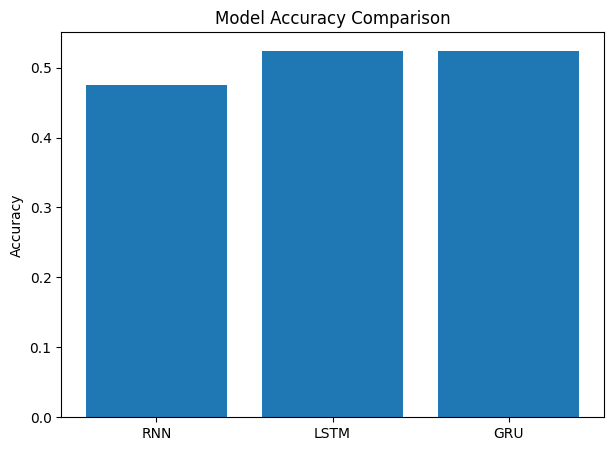

In [37]:
models = ['RNN', 'LSTM', 'GRU']
accuracies = [rnn_accuracy, lstm_accuracy, gru_accuracy]

plt.figure(figsize=(7,5))
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

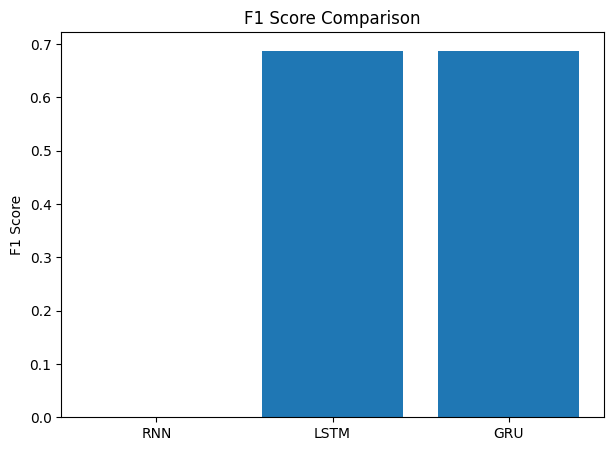

In [45]:
f1_scores = [rnn_f1, lstm_f1, gru_f1]

plt.figure(figsize=(7,5))
plt.bar(models, f1_scores)
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison")
plt.show()

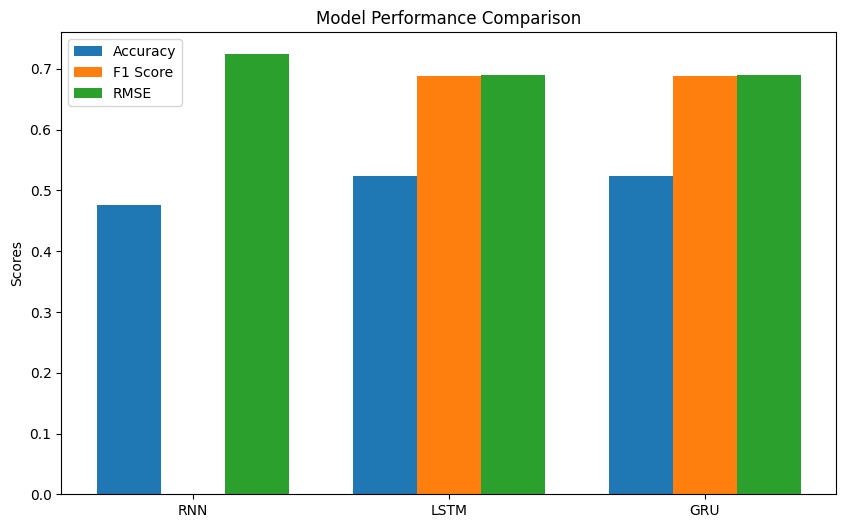

In [48]:
models = ['RNN', 'LSTM', 'GRU']
accuracies = [rnn_accuracy, lstm_accuracy, gru_accuracy]
f1_scores = [rnn_f1, lstm_f1, gru_f1]
rmse_scores = [rnn_rmse, lstm_rmse, gru_rmse]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, accuracies, width, label='Accuracy')
plt.bar(x, f1_scores, width, label='F1 Score')
plt.bar(x + width, rmse_scores, width, label='RMSE')

plt.xticks(x, models)
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.legend()

plt.show()

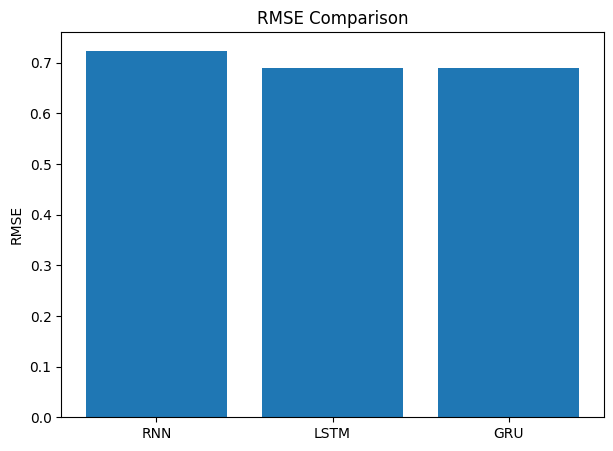

In [39]:
rmse_scores = [rnn_rmse, lstm_rmse, gru_rmse]

plt.figure(figsize=(7,5))
plt.bar(models, rmse_scores)
plt.ylabel("RMSE")
plt.title("RMSE Comparison")
plt.show()

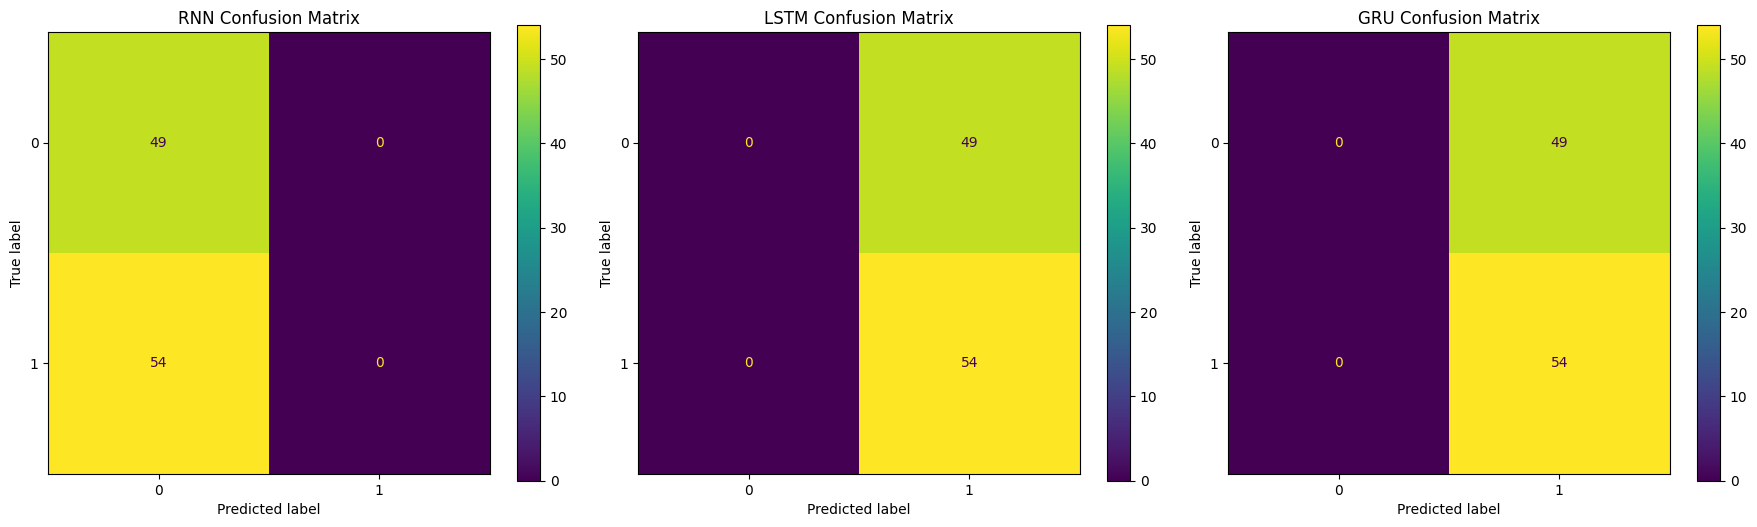

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18,5))

cm_rnn = confusion_matrix(y_test, rnn_pred)
cm_lstm = confusion_matrix(y_test, lstm_pred)
cm_gru = confusion_matrix(y_test, gru_pred)

ConfusionMatrixDisplay(cm_rnn).plot(ax=axes[0])
axes[0].set_title('RNN Confusion Matrix')

ConfusionMatrixDisplay(cm_lstm).plot(ax=axes[1])
axes[1].set_title('LSTM Confusion Matrix')

ConfusionMatrixDisplay(cm_gru).plot(ax=axes[2])
axes[2].set_title('GRU Confusion Matrix')

plt.tight_layout()
plt.show()

In [41]:
comparison_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy],
    'F1 Score': [rnn_f1, lstm_f1, gru_f1],
    'RMSE': [rnn_rmse, lstm_rmse, gru_rmse]
})

print(comparison_df)

  Model  Accuracy  F1 Score      RMSE
0   RNN  0.475728  0.000000  0.724066
1  LSTM  0.524272  0.687898  0.689730
2   GRU  0.524272  0.687898  0.689730
